# 01 — Data Exploration

**Goal:** Verify the data pipeline works end-to-end before building feature modules.

Steps:
1. Load all data sources for a single season (fast sanity check)
2. Profile key columns: shapes, dtypes, null counts
3. Sanity check: compute PPR points from weekly data, compare to `fantasy_points_ppr` column
4. Visualize distributions and check for data quality issues
5. Audit player ID joins across data sources

In [12]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import TRAINING_SEASONS, PROJECTION_SEASON, POSITIONS
from data.loader import load_pbp, load_weekly, load_seasonal, load_rosters, load_snap_counts, load_ngs
from data.cleaning import clean_pbp, clean_weekly, clean_rosters
from utils.scoring import calculate_fantasy_points, DEFAULT_COLUMN_MAP
from config import PPR_SCORING

print('Imports OK')

Imports OK


## 1. Load Data (Single Season First)

In [13]:
# Load one season first to verify the pipeline quickly
EXPLORE_SEASON = [2024]

print('Loading PBP...')
pbp_raw = load_pbp(EXPLORE_SEASON)
print(f'  PBP: {pbp_raw.shape} rows × cols')

print('Loading weekly...')
weekly_raw = load_weekly(EXPLORE_SEASON)
print(f'  Weekly: {weekly_raw.shape}')

print('Loading rosters...')
rosters_raw = load_rosters(EXPLORE_SEASON)
print(f'  Rosters: {rosters_raw.shape}')

Loading PBP...
2024 done.
  PBP: (49492, 396) rows × cols
Loading weekly...
Downcasting floats.
  Weekly: (5597, 53)
Loading rosters...
  Rosters: (3215, 37)


In [14]:
# Clean data
pbp = clean_pbp(pbp_raw)
weekly = clean_weekly(weekly_raw)
rosters = clean_rosters(rosters_raw)

print(f'PBP after cleaning: {pbp.shape}')
print(f'\nPlay types in cleaned PBP:')
print(pbp['play_type'].value_counts())

PBP after cleaning: (35050, 396)

Play types in cleaned PBP:
play_type
pass    20006
run     15044
Name: count, dtype: int64


## 2. Profile PBP Key Columns

In [15]:
# Key columns for factor engineering
key_cols = ['epa', 'wp', 'cpoe', 'air_yards', 'yards_after_catch', 'yac_epa',
            'complete_pass', 'pass_touchdown', 'rush_touchdown', 'sack',
            'receiver_player_id', 'rusher_player_id', 'passer_player_id',
            'posteam', 'play_type', 'yardline_100', 'qtr', 'game_half']

available_cols = [c for c in key_cols if c in pbp.columns]
missing_cols = [c for c in key_cols if c not in pbp.columns]

print(f'Key columns present: {len(available_cols)}/{len(key_cols)}')
if missing_cols:
    print(f'Missing: {missing_cols}')

# Null rates for key columns
null_pct = pbp[available_cols].isnull().mean().sort_values(ascending=False)
print('\nNull rates for key columns:')
print(null_pct[null_pct > 0].round(3))

Key columns present: 18/18

Null rates for key columns:
yards_after_catch     0.654
rusher_player_id      0.571
cpoe                  0.494
receiver_player_id    0.491
air_yards             0.472
yac_epa               0.472
passer_player_id      0.429
dtype: float64


EPA stats:
  min=-12.689, max=8.541
  mean=0.010, std=1.387
  Outliers (|epa| > 15): 0


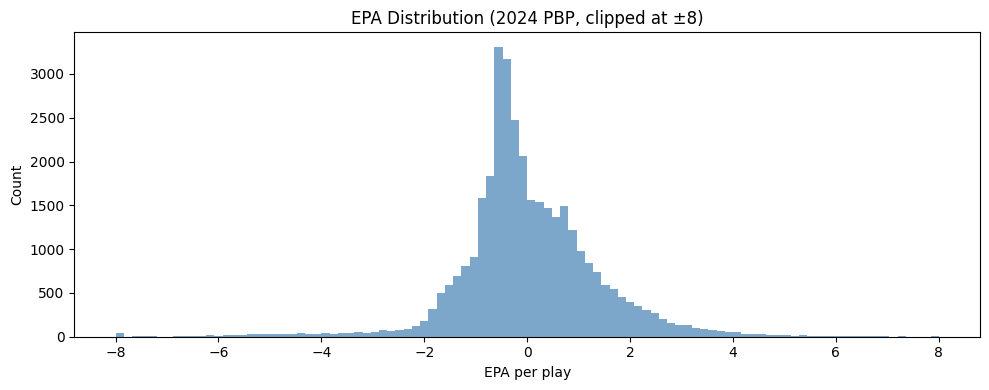

In [16]:
# EPA distribution check
if 'epa' in pbp.columns:
    epa = pbp['epa'].dropna()
    print(f'EPA stats:')
    print(f'  min={epa.min():.3f}, max={epa.max():.3f}')
    print(f'  mean={epa.mean():.3f}, std={epa.std():.3f}')
    n_outliers = ((epa < -15) | (epa > 15)).sum()
    print(f'  Outliers (|epa| > 15): {n_outliers}')
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(epa.clip(-8, 8), bins=100, color='steelblue', alpha=0.7)
    ax.set_xlabel('EPA per play')
    ax.set_ylabel('Count')
    ax.set_title('EPA Distribution (2024 PBP, clipped at ±8)')
    plt.tight_layout()
    plt.show()

## 3. Fantasy Point Sanity Check

In [17]:
# Compute PPR points from weekly data using our scoring function
computed_pts = calculate_fantasy_points(weekly, PPR_SCORING, DEFAULT_COLUMN_MAP)

# Compare to the official fantasy_points_ppr column
if 'fantasy_points_ppr' in weekly.columns:
    official_pts = weekly['fantasy_points_ppr']
    
    # Only compare rows where both are non-null and non-zero
    valid = (official_pts.notna()) & (official_pts > 0) & (computed_pts.notna())
    
    diff = (computed_pts[valid] - official_pts[valid]).abs()
    pct_within_1pt = (diff < 1.0).mean()
    pct_within_5pt = (diff < 5.0).mean()
    
    print(f'Scoring sanity check ({valid.sum()} player-weeks):')
    print(f'  % within 1pt of official: {pct_within_1pt:.1%}')
    print(f'  % within 5pts of official: {pct_within_5pt:.1%}')
    print(f'  Max absolute difference: {diff.max():.2f} pts')
    
    if pct_within_1pt < 0.8:
        print('⚠️  Warning: Large discrepancy with official points. Check column_map.')
    else:
        print('✓ Scoring function matches official data within expected tolerance')
else:
    print('fantasy_points_ppr column not found — check nfl_data_py version')

Scoring sanity check (5147 player-weeks):
  % within 1pt of official: 99.6%
  % within 5pts of official: 99.6%
  Max absolute difference: 6.00 pts
✓ Scoring function matches official data within expected tolerance


In [18]:
# Top 10 PPR scorers in 2024 by total fantasy points
if 'fantasy_points_ppr' in weekly.columns and 'player_display_name' in weekly.columns:
    top_scorers = (
        weekly.groupby(['player_id', 'player_display_name', 'position'])
        ['fantasy_points_ppr'].sum()
        .sort_values(ascending=False)
        .head(20)
        .reset_index()
    )
    top_scorers.columns = ['player_id', 'name', 'pos', 'fpts']
    top_scorers['fpts'] = top_scorers['fpts'].round(1)
    print('Top 20 PPR scorers 2024:')
    print(top_scorers.to_string(index=False))

Top 20 PPR scorers 2024:
 player_id              name pos       fpts
00-0034796     Lamar Jackson  QB 471.500000
00-0034844    Saquon Barkley  RB 455.700012
00-0034857        Josh Allen  QB 438.299988
00-0039910    Jayden Daniels  QB 428.200012
00-0036389       Jalen Hurts  QB 411.600006
00-0036900     Ja'Marr Chase  WR 403.000000
00-0039139      Jahmyr Gibbs  RB 390.399994
00-0034855    Baker Mayfield  QB 381.500000
00-0032764     Derrick Henry  RB 381.399994
00-0036442        Joe Burrow  QB 372.799988
00-0033873   Patrick Mahomes  QB 348.399994
00-0038542    Bijan Robinson  RB 341.700012
00-0036963 Amon-Ra St. Brown  WR 337.899994
00-0033106        Jared Goff  QB 333.700012
00-0039732            Bo Nix  QB 331.299988
00-0036322  Justin Jefferson  WR 328.299988
00-0037248        James Cook  RB 324.299988
00-0035659    Terry McLaurin  WR 322.500000
00-0034869       Sam Darnold  QB 319.700012
00-0035700       Josh Jacobs  RB 314.200012


## 4. Visualize Distributions

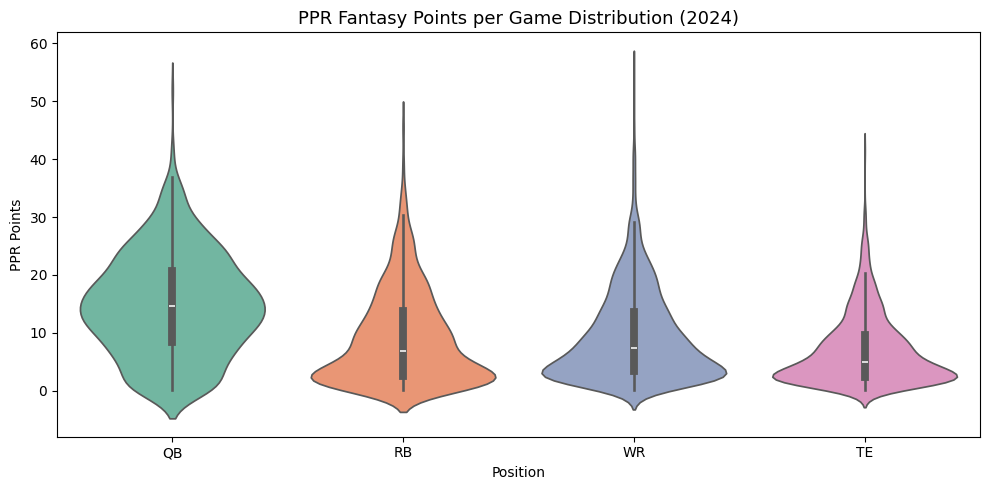

In [19]:
# PPR points per game by position (violin plot)
if 'fantasy_points_ppr' in weekly.columns and 'position' in weekly.columns:
    pos_weekly = weekly[
        weekly['position'].isin(POSITIONS) &
        (weekly['fantasy_points_ppr'] > 0)
    ]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.violinplot(
        data=pos_weekly, x='position', y='fantasy_points_ppr',
        order=POSITIONS, palette='Set2', ax=ax
    )
    ax.set_title('PPR Fantasy Points per Game Distribution (2024)', fontsize=13)
    ax.set_xlabel('Position')
    ax.set_ylabel('PPR Points')
    plt.tight_layout()
    plt.show()

## 5. Player ID Join Audit

In [20]:
# Check what fraction of PBP receiver_player_ids match to roster player_ids
if 'receiver_player_id' in pbp.columns and 'player_id' in rosters.columns:
    pbp_receiver_ids = set(pbp['receiver_player_id'].dropna().unique())
    roster_ids = set(rosters['player_id'].dropna().unique())
    matched = pbp_receiver_ids & roster_ids
    match_rate = len(matched) / len(pbp_receiver_ids) if pbp_receiver_ids else 0
    print(f'PBP receiver IDs matchable to rosters: {match_rate:.1%} ({len(matched)}/{len(pbp_receiver_ids)})')
    
    if match_rate < 0.85:
        print('⚠️  Warning: Low ID match rate. Check player_id column naming.')
    else:
        print('✓ Player ID join looks healthy')

PBP receiver IDs matchable to rosters: 100.0% (497/497)
✓ Player ID join looks healthy


## 6. Load Full Training Window

In [21]:
# Load full 5-year training window (will download + cache if not cached)
print('Loading full training window...')
print('Note: First run downloads ~2-3 GB of PBP data. This may take several minutes.')

pbp_all = load_pbp(TRAINING_SEASONS)
weekly_all = load_weekly(TRAINING_SEASONS)

print(f'\nFull PBP: {pbp_all.shape}')
print(f'Full weekly: {weekly_all.shape}')
print(f'\nSeasons in PBP: {sorted(pbp_all["season"].unique())}')
print(f'Records per season:')
print(pbp_all.groupby('season').size())

Loading full training window...
Note: First run downloads ~2-3 GB of PBP data. This may take several minutes.
2020 done.
2021 done.
2022 done.
2023 done.
Downcasting floats.

Full PBP: (246218, 396)
Full weekly: (28026, 53)

Seasons in PBP: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Records per season:
season
2020    47705
2021    49922
2022    49434
2023    49665
2024    49492
dtype: int64


In [22]:
# Summary table: records per season across all data sources
for name, df in [('PBP', pbp_all), ('Weekly', weekly_all)]:
    if 'season' in df.columns:
        counts = df.groupby('season').size().rename(name)
        print(counts.to_string())
        print()

season
2020    47705
2021    49922
2022    49434
2023    49665
2024    49492

season
2020    5447
2021    5698
2022    5631
2023    5653
2024    5597

